# Biblioteca Finanzas en Python

### Creado por Augusto Chan P.

### Librerías a utilizar

In [1]:
import numpy as np
import yfinance as yf
import pandas as pd
import scipy.optimize as sco
import matplotlib as plt
from scipy.stats import norm, t

##  Básicos: Obtener precios, retornos y su comportamiento

Bajo la teoría financiera moderna los precios contienen información relevante sobre del activo financiero y la compañia, dependiendo de una noticia o la información relevelada en un reporte trimestral, el público inversionista responderá ante esto, ya sea comprando o vendiendo las acciones, moviendo los precios a la alta o a la baja. Por ejemplo, una noticia sobre el acuerdo comercial multimillonario entre una compañia y el gobierno hará que los precios suban por lo tanto la movida a la alta se debe a una noticia positiva, cosa que se refleja en el precio del activo.

### Función para obtener precios (CHLOV)

En esta función se utliza la librería de yfinance para poder obtener los precios de un activo en particular:
- **Precio de cierre:** Es el precio con el que cerró el activo ese día
- **Precio máximo:** Es el precio máximo que alcanzó el activo en ese día
- **Precio mínimo:** Es el precio mínimo que llegó a tener el activo ese día
- **Precio de apertura:** Es el precio con el aperturó ese día, que no es el mismo que el de cierre del día anterior
- **Volumen:** La cantidad de acciones que fueron negociadas ese día

Para esto la función llamada "get_prices" descarga desde la base de datos de yahoo finanzas los precios del activo durante el intervalo de fechas seleccionadas finalmente devolviendo una tabla con la infromación pedida.

In [2]:
import yfinance as yf

def get_prices(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
    # Si viene con MultiIndex, lo aplanamos
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.droplevel(1)
    return data

In [3]:
precios_AAPL = get_prices('AAPL', '2023-12-17', '2025-12-17')
precios_AAPL.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2023-12-18,194.057343,194.790425,192.571376,194.255468,55751900
2023-12-19,195.097504,195.107405,194.057324,194.324802,40714100
2023-12-20,193.007248,195.830575,193.007248,195.057874,52242800
2023-12-21,192.858643,195.236198,191.689689,194.265371,46482500
2023-12-22,191.788773,193.581837,191.164662,193.353978,37149600


### Función para obtener precios de cierre ajustados para múltiples valores

Los precios de cierre son importantes porque reflejan lo que paso ese día, muestran el comportanmiento del activo durante ese día, entender esto es importante porque los precios de cierre junto con sus rendimientos es la base de muchos de los cálculos dentro de las finanzas cuantitativas.

In [4]:
def get_closing_prices(tickets, start_date, end_date):
    #Si las fechas son válidas entonces
    if tickets and start_date < end_date:
        
        #Descarga los precios de cierre ajustados de los tickets en las fechas seleccionadas
        raw = yf.download(tickets, start=start_date, end=end_date, auto_adjust=True)["Close"]
        #Los precios ajsutados son ideales cuando hacemos análisis cuantitativo, pero para contable no
        
        valid_tickets = [] #Lista donde ponemos los simbolos

        #Por cada ticket que tengamos en tickets si no esta ponemos que no fue encontrado
        for ticket in tickets: 
            if ticket not in raw.columns or raw[ticket].dropna().empty:
                print(f"El ticket '{ticket}' no fue encontrado o no tiene datos.")
            else: #si se encuentra lo agregamos a la lista
                valid_tickets.append(ticket)

        # Filtrar activos válidos
        assets = raw[valid_tickets].dropna(axis=1, how='all')
        
        return assets

Para poder usar la función debemos de ponder los tickets de las acciones en un list [], para luego poner las fechas en el orden de AÑO-MES-DIAS.

In [5]:
#Ejemplo
portfolio1_prices = get_closing_prices(['AAPL', 'MSFT', 'JNJ'], '2023-12-17', '2025-12-17')

[*********************100%***********************]  3 of 3 completed


In [6]:
portfolio1_prices.head()

Ticker,AAPL,MSFT,JNJ
Date,,,
2023-12-18,194.057343,367.175415,146.194809
2023-12-19,195.097504,367.776520,147.154160
2023-12-20,193.007248,365.175293,144.153900
2023-12-21,192.858643,368.052399,145.630493
2023-12-22,191.788773,369.077118,146.213623


## Obtener rendimientos

### Obtener retornos simples

Los retornos simples miden el cambio porcentual del precio de un activo entre dos periodos consecutivos. Indican cuánto gana o pierde un inversionista en relación con el precio inicial. obtenerlo es bastante sencillo, es la diferencia del precio del día de hoy, menos el del día anterior todo esto entre el el precio del día anterior

In [7]:
def simple_returns(closing_prices):
    return closing_prices.pct_change().dropna()

### Obtener retornos logaritmicos

Los retornos logaritmicos son prefereibles a los retornos simples porque son aditivos en el tiempo y transforman la distribución de precios a una forma más cerana a la normalidad estadística, lo que de manera resumida realizar cálculos de una manera más sencilla y adecuada para modelos matemáticos y de predicción.

In [8]:
#Los rendimientos Logaritmicos son más exactos que el rendimiento simple (pf-pa / pf)

def get_log_returns(closing_prices):
    return np.log(closing_prices / closing_prices.shift(1)).dropna()
    #Logaritmo Natural(Precio actual / precio anterior)

In [9]:
#Ejemplo de uso de la función
portfolio1_returns = get_log_returns(portfolio1_prices)

In [10]:
portfolio1_returns.head()

Ticker,AAPL,MSFT,JNJ
Date,,,
2023-12-19,0.005346,0.001636,0.006541
2023-12-20,-0.010772,-0.007098,-0.020599
2023-12-21,-0.000770,0.007848,0.010191
2023-12-22,-0.005563,0.002780,0.003996
2023-12-26,-0.002845,0.000213,0.004365


### Diferencias entre retornos simples y logarítmicos

Los retornos simples midel el cambio porcnetual del precio respecto al día anterior, estos son intuitivos y fáciles de interpretar, ya que representan directamente la ganancia o pérdida relaitva de una inversión, pero no son aditivos en el tiempo.

Por el otro lado los retornos logarítmicos midel el cambio porcentual continuo del precio, Se obtienen aplicando el logaritmo natural al cociente de precios consecuitovs, estos son aditivos en el tiempo, son ideales para las finanzas cuantitativas.

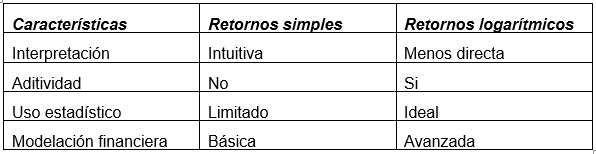

### Obtener estadísticas relevantes como función

- **Retornos**: Es la ganancia o pérdida del activo, si es en promedio subio un 10% anual por ejemplo. 
- **Volatilidad**: Mide que tanto varían los precios o retornos respecto a su promedio.
- **Varianza**: sirve para entender que tan lejos están los números del centro, es vital para el análisis de riesgo.
- **Sharp ratio:** Es la relación riesgo-rendimiento, dice si la ganancia que estás obtiendo vale la pena en relación al riesgo que estás asumiendo , un sharp mayor o cercano a uno se considera que sus ganancias compensan a sus riesgos.  
- **Skewness (Asimetría):** Indica si los datos están balanceados o si se inclinan más hacia un lado mientras más alto quiere decir que hay más posilidades de ganancia
- **Kurtosis:** muestra ue tan probables son los eventos extremos, un número alto indica que suceden de más más frecuente de los normal.

In [11]:
def get_descriptive_stats(returns, risk_free_rate, days):
    
    #Si no tenemos días, se calcula usando el número de filas que tenemos en los retornos
    if days is None:
        days = len(returns) #se aconseja poner poner 252 días 
    
    #Convertirmos la tasa libre de riesgo anualizada a diaria para poder realizar los cálculos
    rf_daily = (1 + risk_free_rate)**(1 / days) - 1
    
    #Creamos el dataframe 
    stats = pd.DataFrame(index=returns.columns)
    
    stats["returns"] = returns.mean() * days
    stats["Volatility"] = returns.std() * np.sqrt(days)
    stats["Variance"] = returns.var() * days
    stats["Sharpe Ratio"] = ((returns.mean() - rf_daily) / returns.std() )* np.sqrt(days)
    stats["Skewness"] = returns.skew()
    stats["Kurtosis"] = returns.kurt()

    return stats

In [12]:
#Ejemplo de uso de la función
portfolio_summary = get_descriptive_stats(portfolio1_returns, 0.04, 252)
portfolio_summary

,returns,Volatility,Variance,Sharpe Ratio,Skewness,Kurtosis
Ticker,,,,,,
AAPL,0.174988,0.278297,0.077449,0.487838,0.620310,11.549142
MSFT,0.131240,0.221280,0.048965,0.415837,0.337219,7.109042
JNJ,0.180850,0.175886,0.030936,0.805212,-0.354070,7.568930


### Obtener un elemento aislado de la tabla

In [13]:
real_returns = portfolio_summary.loc[:, 'returns']
real_returns

Ticker
AAPL    0.174988
MSFT    0.131240
JNJ     0.180850
Name: returns, dtype: float64

### Matriz de covarianza

Una matriz de covarianza nos permite calcular si dos vairbles o en este caso activos tienden a aumentar o a disminuir al mismo tiempo, en donde la  si es positivo es que ambas suben pero si es negativo quiere decir que cuando una sube la otra tiende a bajar, y los valores en diagonal muestran es decir del mismo activo muestra varianza de cada variable.

In [14]:
portfolio1_cov = portfolio1_returns.cov()
portfolio1_cov

Ticker,AAPL,MSFT,JNJ
Ticker,,,
AAPL,0.000307,0.000116,0.000008
MSFT,0.000116,0.000194,-0.000020
JNJ,0.000008,-0.000020,0.000123


### Matriz de correlación

La matriz de correlación permite observar de manera sencilla que tan pegados están los activos, activos que están cercanos a 1 tendrán una correlación más alta, mientras que activos cercanos a cero o con valor negativo tendrán una correlación baja, esto se puede deber a que pertenecen a la misma industria o venden un producto similar.

In [15]:
portfolio1_corr = portfolio1_returns.corr()
portfolio1_corr

Ticker,AAPL,MSFT,JNJ
Ticker,,,
AAPL,1.000000,0.475879,0.040459
MSFT,0.475879,1.000000,-0.131700
JNJ,0.040459,-0.131700,1.000000


# Métricas de Riesgo - Rendimiento sistemático

## Betas

La beta es una medida estadística de riesgo que mide el riesgo sistemático, y se refiere al riesgo que no podemos diversificar y afecta a todas las empresas sin importar el sector al que pertenezcan o actividades que realicen. 
La beta se lee de la siguiente manera:

- Si la beta es igual a uno quiere decir que su riesgo es igual al del mercado, si el mercado baja 10% entonces nuestra acción igual bajará un 10%.

- Si la beta es menor a uno quiere decir que su riesgo es menor al del mercado, si la beta es de 0.50 y el mercado baja un 10% entonces mi acción bajará solo un 5%, pero si el mercado sube 10% entonces mi acción solo subirá un 5%.

- Si la beta es mayor a uno quiere decir que su riesgo es mayor al del mercado, si la beta es de 1.50 y el mercado baja un 10% entonces mi acción bajará solo un 15%, pero si el mercado sube 10% entonces mi acción solo subirá un 15%.

Comprender el funcionamiento es vital para armar una cartera de inversiones, al igual que comprender el periodo macroeconómico en el que vamos.


### Obtener Betas de los activos

Para obtener la beta podemos usar la librería de yahoo finanzas, el cual agarra la beta que aparece en la página de yahoo finance, el cual es una beta de a 5 años con una frecuencia de 5 años, y saber esto es importante porque si vamos a hacer otros datos como CAPM es importante usar datos de esa misma temporalidad.

In [16]:
def get_betas(tickers):
    betas = {}
    for ticker in tickers:
        asset = yf.Ticker(ticker)
        beta_value = asset.info.get("beta")
        betas[ticker] = beta_value

    df_betas = pd.DataFrame.from_dict(betas, orient='index', columns=['Beta'])
    return df_betas

In [17]:
portfolio1_betas = get_betas(['AAPL', 'MSFT', 'JNJ'])
portfolio1_betas

,Beta
AAPL,1.107
MSFT,1.070
JNJ,0.349


### Calcular betas

Otra opción es calcular la beta de manera manual, el cual es la siguiente:

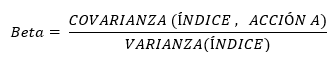

In [18]:
def calculate_beta(returns_asset, returns_market):
    covariance = np.cov(returns_asset, returns_market)[0][1]
    variance = np.var(returns_market)
    return covariance / variance

## Capital Assets Price Model

El capital asset Price model es de gran utilidad porque nos permite ver el rendimiento esperado de un activo, o portafolio dadas ciertas características como el riesgo sistemático, la tasa libre de riesgo y el desempeño del índice de referencia.

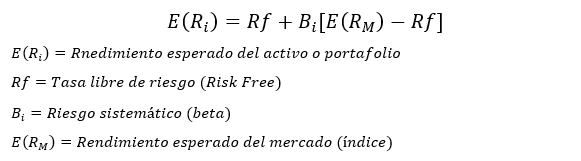

### Obtener el CAPM en un dataframe

In [19]:
def CAPM_df(df_betas, risk_free_rate, market_return):
    capm_values = risk_free_rate + df_betas * (market_return - risk_free_rate)
    capm_values.columns = ['CAPM']
    return capm_values

In [20]:
portfolio1_CAPM = CAPM_df(portfolio1_betas, 0.07, 0.11)
portfolio1_CAPM

,CAPM
AAPL,0.11428
MSFT,0.11280
JNJ,0.08396


### Obtener el CAPM individual

In [21]:
def CAPM_i(beta_i, risk_free_rate, market_return):
    return risk_free_rate + beta_i * (market_return - risk_free_rate)

In [22]:
CAPM_i(0.80,0.07,0.11)

0.10200000000000001

## Alpha

Es una medida estadística que evalúa el desempeño de un portafolio o un activo en base a un índice de referencia o descontando el CAPM, cuando es positiva quiere decir que estamos superando el rendimiento esperado.

### Calcular alpha en un dataframe

In [23]:
def alpha_df(real_returns, capm_returns):
    alpha = real_returns - capm_returns.squeeze()
    return alpha.to_frame(name='Alpha')

In [24]:
alpha_df(real_returns,portfolio1_CAPM)

,Alpha
Ticker,
AAPL,0.060708
MSFT,0.018440
JNJ,0.096890


### Calcular el alpha individual

In [25]:
def alpha_i(real_returns, capm_returns):
    return real_returns - capm_returns

In [26]:
alpha_i(0.10,0.08)

0.020000000000000004

### Clase de riesgo sistemático

In [27]:
class systematic_risk:
    def __init__(self, real_returns):
        self.real_returns = real_returns

    def get_betas(self, tickers):
        betas = {}
        for t in tickers:
            beta = yf.Ticker(t).info.get("beta")
            betas[t] = beta
        return pd.DataFrame.from_dict(betas, orient="index", columns=["Beta"])

    def compute_capm(self, df_betas, risk_free_rate, market_return):
        return CAPM_df(df_betas, risk_free_rate, market_return)

    def compute_alpha(self, capm_returns):
        alpha = self.real_returns.mean() - capm_returns.squeeze()
        return alpha.to_frame(name="Alpha")

    def summary(self, tickers, risk_free_rate, market_return):
        df_betas = self.fetch_betas(tickers)
        df_capm = self.compute_capm(df_betas, risk_free_rate, market_return)
        df_alpha = self.compute_alpha(df_capm)

        return (
            df_betas
            .join(df_capm)
            .join(df_alpha)
        )


# Optimización de portafolios

La optimización de portafolios es un tema crucial dentro de las finanzas cuantitativas, ya que buscamos obtener el mayor rendimiento posible asumiendo la menor cantidad de riesgo, a su vez que buscamos obtener un portafolio diversificado, ya que así disminuimos el riesgo.

## Frontera eficiente

Este representa los portafolios con la tasa de rendimiento máximo por cada nivel de riesgo dado o el riesgo mínimo por cada nivel de rendimiento.

### Obtener pesos máximos y mínimos

Los pesos máximos y mínimos representan el máximo o mínimo peso que podemos asignar a un solo activo, ya que los resultados de la frontera eficiente pueden alocar bastante peso a un solo activo, así que representa una manera más “real” de asignar portafolios.
Para poder esto creamos una clase llamada “BoundsManager” pero no es necesario rellenar esta clase”

In [28]:
Symb = ['AAPL', 'MSFT', 'JNJ']

In [29]:
class BoundsManager:
    '''Esta clase nos permite asignar máximos y minimos al portafolio, pero por default se manejan como min = 0 y max = 1
    Por lo que no es necesario rellenar esta parte'''
    
    def __init__(self, symbols, min_weight=0.0, max_weight=1.0):
        self.symbols = symbols
        self.min_weight = min_weight
        self.max_weight = max_weight

    def get_bounds(self):
        noa = len(self.symbols)
        return tuple((self.min_weight, self.max_weight) for _ in range(noa))

### Métricas del portafolio

Para la clase de **PortfolioMetrics** creamos las funciones con las operaciones que utilizaremos para calcular nuestra frontera eficiente, que es la función para obtener el rendimiento, obtener la volatilidad y calcular el Sharp ratio.

In [30]:
class PortfolioMetrics:
    def __init__(self, log_returns, risk_free_rate, risk_aversion):
        self.log_returns = log_returns
        self.risk_free_rate = risk_free_rate
        self.risk_aversion = risk_aversion
        self.cov_matrix = log_returns.cov() * 252
    
    #Función para obtener el rendimiento
    def port_ret(self, weights):
        return np.sum(self.log_returns.mean() * weights) * 252
    
    #Función para obtener la volatbilidad 
    def port_vol(self, weights):
        return np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix, weights)))

    #Función Objetivo: Calcula el Sharp Ratio 
    def sharpe_ratio(self, weights):
        return (self.port_ret(weights) - self.risk_free_rate) / self.port_vol(weights)

### Optimización de portafolios en base a las funciones objetivo

Las funciones objetivo representan los portafolios que queremos obtener en base a las acciones que hemos escogido, la primera es el portafolio de mínima varianza que es el portafolio que busca minimizar la volatilidad, mientras que el segundo el portafolio con mayor Sharp ratio es el portafolio que busca maximizar la relación riesgo-rendimiento. 

In [31]:
class EfficientFrontier:
    def __init__(self, symbols, metrics, bounds_manager=None):
        self.symbols = symbols
        self.metrics = metrics
        self.bounds_manager = bounds_manager or BoundsManager(symbols) 

        self.results_stats = {}
        self.results_weights = {}
    
    # = = = = = OBJETIVOS DE OPTIMIZACIÓN = = = = =
    
    # --- Optimización mínima varianza ---
    def minimize_variance(self, bounds=None):
        noa = len(self.symbols)
        bounds = self.bounds_manager.get_bounds()
        cons = ({'type':'eq','fun': lambda x: np.sum(x) - 1})
        eweights = np.array(noa * [1./noa])

        optv = sco.minimize(self.metrics.port_vol, eweights, method='SLSQP',
                            bounds=bounds, constraints=cons)

        weights = optv['x']
        ret = self.metrics.port_ret(weights)
        vol = self.metrics.port_vol(weights)
        var = vol**2
        sharpe = (ret - self.metrics.risk_free_rate) / vol
        utility = ret - (self.metrics.risk_aversion/2)*var

        # Guardar resultados
        self.results_stats['min_var'] = {
            'return': ret, 'volatility': vol, 'variance': var,
            'sharpe': sharpe, 'Exp Utility': utility
        }
        self.results_weights['min_var'] = dict(zip(self.symbols, weights.round(4)))

        return self.results_stats['min_var'], self.results_weights['min_var']

    # --- Optimización máximo Sharpe ---
    def maximize_sharpe(self, bounds=None):
        noa = len(self.symbols)
        bounds = self.bounds_manager.get_bounds()
        cons = ({'type':'eq','fun': lambda x: np.sum(x) - 1})
        eweights = np.array(noa * [1./noa])

        def min_func_sharpe(weights):
            return -(self.metrics.port_ret(weights) - self.metrics.risk_free_rate) / self.metrics.port_vol(weights)

        opts = sco.minimize(min_func_sharpe, eweights, method='SLSQP',
                            bounds=bounds, constraints=cons)

        weights = opts['x']
        ret = self.metrics.port_ret(weights)
        vol = self.metrics.port_vol(weights)
        var = vol**2
        sharpe = (ret - self.metrics.risk_free_rate) / vol
        utility = ret - (self.metrics.risk_aversion/2)*var

        # Guardar resultados
        self.results_stats['max_sharpe'] = {
            'return': ret, 'volatility': vol, 'variance': var,
            'sharpe': sharpe, 'Exp Utility': utility
        }
        self.results_weights['max_sharpe'] = dict(zip(self.symbols, weights.round(4)))

        return self.results_stats['max_sharpe'], self.results_weights['max_sharpe']

    # --- Resumen ---
    def summary(self):
        # DataFrame de estadísticas
        stats_df = pd.DataFrame(self.results_stats).T.round(4)

        # DataFrame de pesos
        weights_df = pd.DataFrame(self.results_weights).T

        return stats_df, weights_df


### Ejemplo de uso

Primero usamos la clase de **PortfolioMetrics()**, que usa los retornos logaritmicos, la tasa libre de riesgo, 
y el coeficiente de aversión, luego usas **EfficienteFrontier()**, que heredará las métricas 
y los simbolos de las acciones que se usaron

In [32]:
metrics = PortfolioMetrics(portfolio1_returns, 0.04, 3)
ef = EfficientFrontier(Symb, metrics)

Es importante aclarar que el método **maximize_sharpe()** de la clase EfficientFrontier
resuelve el problema de optimización y devuelve dos resultados: 
1) Métricas asociadas al portafolio que maximiza la relación riesgo-rendimiento (retorno, volatilidad, Sharpe, etc.),
2) Diccionario con los pesos óptimos de cada activo, identificados por su ticker.

Por ello, el método puede desempaquetarse en dos variables al momento de llamarlo.

In [33]:
# Portafolio máxima SharpRatio
sharpe_stats, sharpe_weights = ef.maximize_sharpe()
ef.maximize_sharpe()

({'return': 0.1682347485009842,
  'volatility': 0.13046600035274036,
  'variance': 0.017021377248041248,
  'sharpe': 0.9828978289690528,
  'Exp Utility': 0.14270268262892233},
 {'AAPL': 0.1244, 'MSFT': 0.2396, 'JNJ': 0.636})

Es importante aclarar que el método **minimize_variance()** de la clase EfficientFrontier
resuelve el problema de optimización y devuelve dos resultados: 
1) Métricas asociadas al portafolio que minimiza la varianza (retorno, volatilidad, Sharpe, etc.),
2) Diccionario con los pesos óptimos de cada activo, identificados por su ticker.

Por ello, el método puede desempaquetarse en dos variables al momento de llamarlo.

In [34]:
# Portafolio mínima varianza
min_stats, min_weights = ef.minimize_variance()
ef.minimize_variance()

#Para llamar a una variable en específico solo tiene que poner ejemplo min_stats['return']

({'return': 0.16275158616009333,
  'volatility': 0.12764950992148116,
  'variance': 0.01629439738319432,
  'sharpe': 0.9616299054778932,
  'Exp Utility': 0.13830999008530184},
 {'AAPL': 0.0601, 'MSFT': 0.3577, 'JNJ': 0.5822})

In [35]:
min_weights

{'AAPL': 0.0601, 'MSFT': 0.3577, 'JNJ': 0.5822}

In [36]:
min_stats

{'return': 0.16275158616009333,
 'volatility': 0.12764950992148116,
 'variance': 0.01629439738319432,
 'sharpe': 0.9616299054778932,
 'Exp Utility': 0.13830999008530184}

In [37]:
stats_df, weights_df = ef.summary()

In [38]:
stats_df

,return,volatility,variance,sharpe,Exp Utility
max_sharpe,0.1682,0.1305,0.0170,0.9829,0.1427
min_var,0.1628,0.1276,0.0163,0.9616,0.1383


In [39]:
weights_df.loc[['min_var']]

,AAPL,MSFT,JNJ
min_var,0.0601,0.3577,0.5822


### Graficar la frontera eficiente

El gráfico muestra un conjunto de portafolios simulados en el plano riesgo–rendimiento. En el eje horizontal se presenta la volatilidad esperada (riesgo) y en el eje vertical el rendimiento esperado.
Cada punto representa un portafolio distinto, y su color indica el Sharpe Ratio, donde los tonos más cálidos corresponden a una mejor relación entre rendimiento y riesgo.

Se destacan dos portafolios clave: el portafolio de máximo Sharpe Ratio, que ofrece la mejor compensación entre riesgo y rendimiento, y el portafolio de mínima volatilidad, que prioriza la reducción del riesgo aun a costa de un menor rendimiento esperado.

En conjunto, el gráfico permite visualizar el compromiso natural entre riesgo y rendimiento y facilita la identificación de portafolios eficientes según distintos objetivos de inversión.


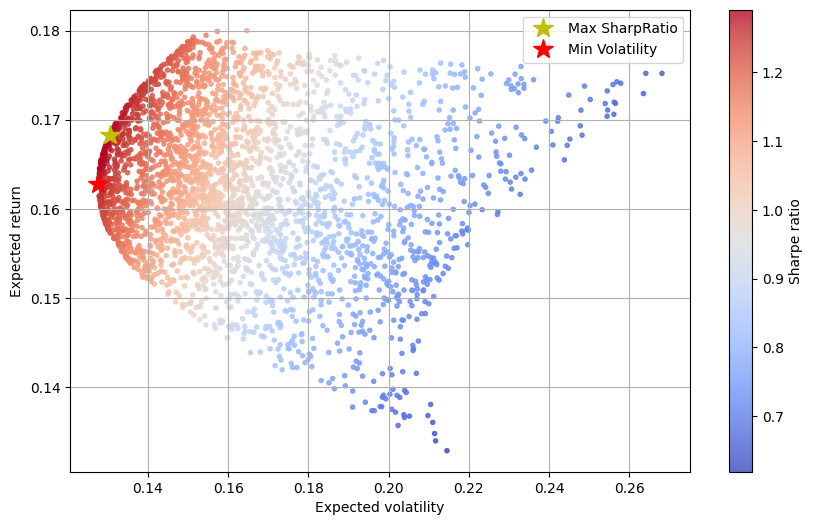

In [40]:
import matplotlib.pyplot as plt

# Corre las optimizaciones
sharpe_stats, sharpe_weights = ef.maximize_sharpe()
min_stats, min_weights = ef.minimize_variance()

# Simula portafolios aleatorios
noa = len(ef.symbols)
prets, pvols = [], []
for _ in range(3000):
    weights = np.random.random(noa)
    weights /= np.sum(weights)
    prets.append(ef.metrics.port_ret(weights))
    pvols.append(ef.metrics.port_vol(weights))

prets = np.array(prets)
pvols = np.array(pvols)

# Graficar directamente
fig, ax = plt.subplots(figsize=(10, 6))

# Simulaciones
scatter = ax.scatter(pvols, prets, c=prets/pvols,
                     marker='.', alpha=0.8, cmap='coolwarm')

# Portafolio máximo Sharpe
ax.plot(sharpe_stats['volatility'], sharpe_stats['return'],
        'y*', markersize=15, label='Max SharpRatio')

# Portafolio mínima varianza
ax.plot(min_stats['volatility'], min_stats['return'],
        'r*', markersize=15, label='Min Volatility')

ax.set_xlabel('Expected volatility')
ax.set_ylabel('Expected return')
fig.colorbar(scatter, label='Sharpe ratio')
ax.legend()
ax.grid(True)

plt.show()

# Value at Risk

## ¿Qué es el VaR y el CVaR?

El Value at Risk o VaR es una medida de riesgo que estima la pérdida máxima esperada dado un **nivel de confianza**, bajo condiciones **normales** de mercado, por ejemplo si tenemos un nivel de confianza de 5% y obtenemos un VaR de -10.30% quiere decir que en 5 de 100 días la pérdida esperada máxima es de -10.30%.

Por el otro lado esta el **Conditional Value at Risk (CVaR)** que es una medida de riesgo que estima la pérdida promedio esperado en los escenario de mayo adversidad, en otras palabras, cuando superamos la pérdida del VaR ¿Qué tanto más podemos perder? todo esto para un nivel de confianza dado.

## VaR histórico

El VaR histórico calcula el riesgo utilizando datos históricos de rendimientos, asumiendo que el comportamiento de atrás es representativo para el futuro. En esta funcion se usan los rendimientos con el nivel de confianza.

Con el CVar histórico calculamos el riesgo promedio de las peores pérdidas utilizando datos históricos de los rendimientos,  En esta funcion se usan los rendimientos con el nivel de confianza.

### Obtener VaR y CVaR histórico

In [80]:
def percentil_var(returns, alpha):

    #Es importante tomar en cuenta que esto devuelve el VaR histórico diario de las acciones
    if isinstance(returns, pd.Series):
        return np.percentile(returns, alpha)

    elif isinstance(returns, pd.DataFrame):
        return returns.aggregate(percentil_var, alpha=alpha)

    else:
        raise TypeError("Expected returns to be dataframe or series")

def percentil_cvar(returns, alpha):

#Es importante tomar en cuenta que esto devuelve el CVaR histórico diario de las acciones
    if isinstance(returns, pd.Series):
        belowVaR = returns <= percentil_cvar(returns, alpha=alpha)
        return returns[belowVaR].mean()

    elif isinstance(returns, pd.DataFrame):
        return returns.aggregate(percentil_cvar, alpha=alpha)

    else:
        raise TypeError("Expected returns to be dataframe or series")

In [44]:
percentil_var(portfolio1_returns,5)

Ticker
AAPL   -0.027421
MSFT   -0.022641
JNJ    -0.015919
dtype: float64

## VaR paramétrico

El VaR paramétrico estima el riesgo del portafolio suponiendo una forma específica para la distribución de los rendimientos y utilizando únicamente el rendimiento esperado y la volatilidad. Para poder usar el VaR paramétrico es importante entender la distribución de los rendimientos, esto se puede observar con el apoyo de un histograma de frecuencia usando .hist()

array([[<Axes: title={'center': 'AAPL'}>,
        <Axes: title={'center': 'MSFT'}>],
       [<Axes: title={'center': 'JNJ'}>, <Axes: >]], dtype=object)

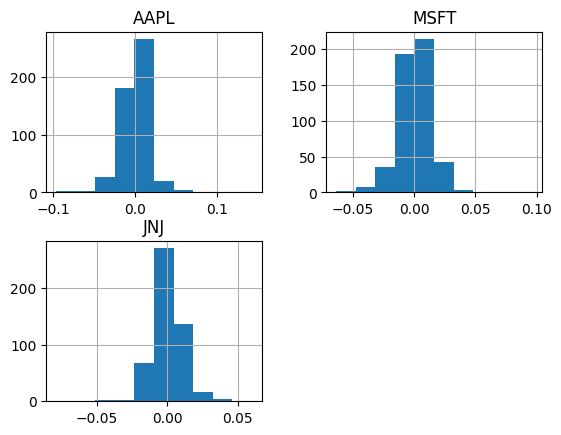

In [46]:
portfolio1_returns.hist()

### ¿Cómo identificar si es una distribución normal o t-student?

En la función podemos escoger una distrubución normal o una distribución t-student, la distribución normal muestra una campana con valores más ceranos a ceros mostrando una cola más "puntiaguda", mientras que una distribución t-student, toma en cuenta colas más pesadas mostrando una campana más "aplanda", siendo más realista en mercados financieros:

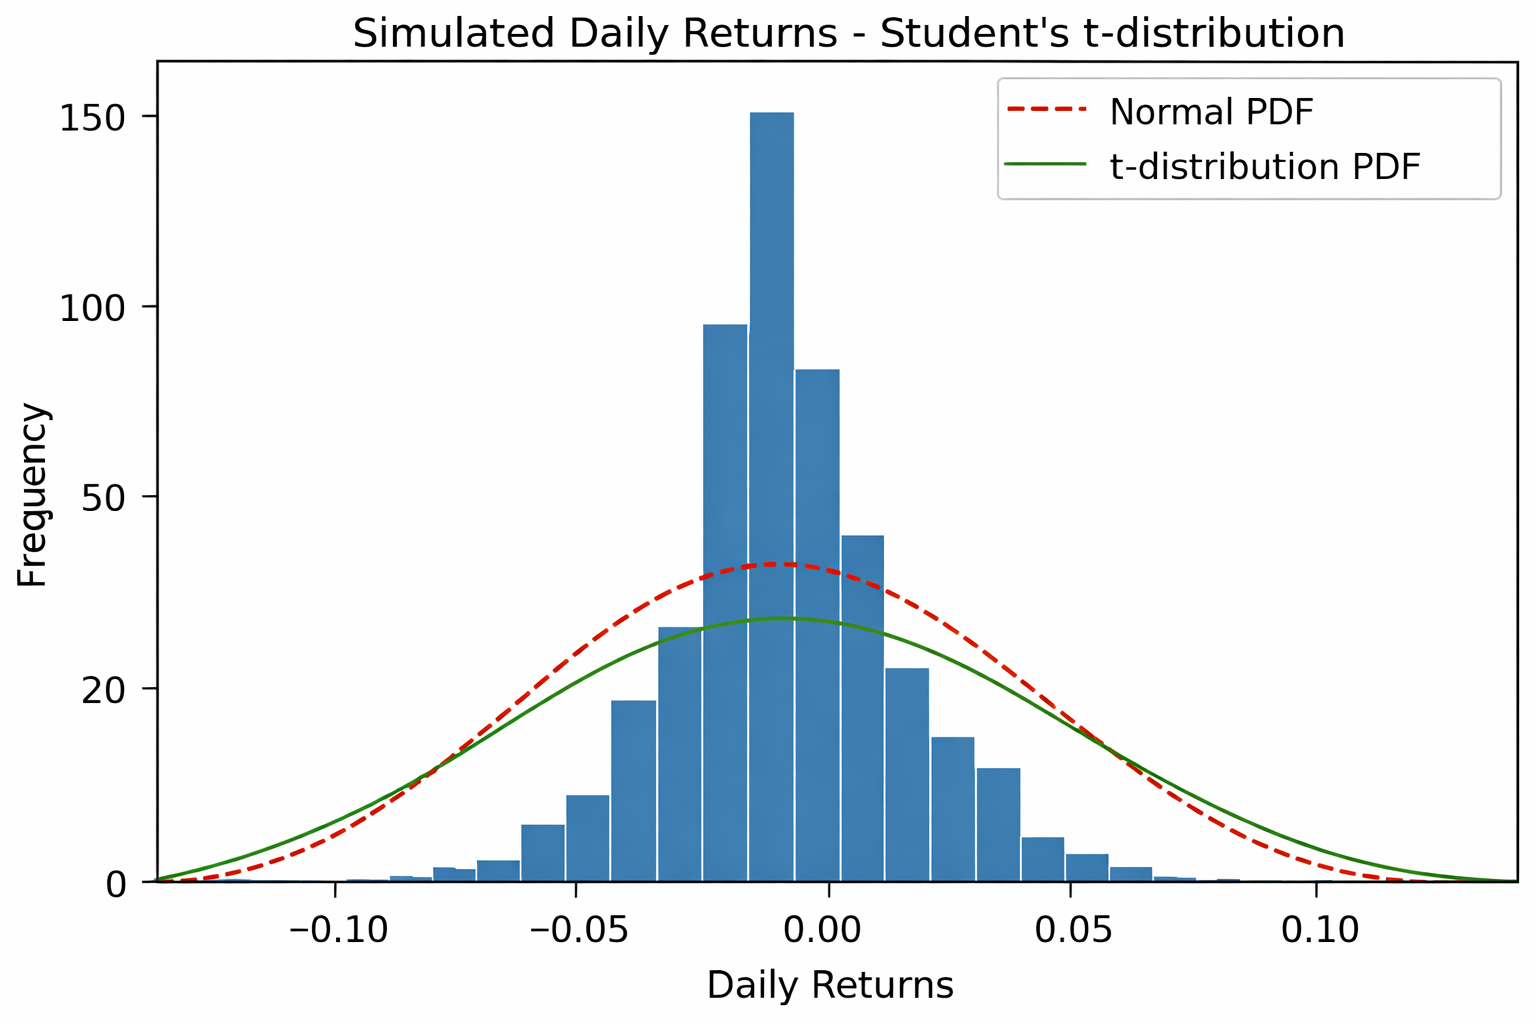

Tal y como se observa con la distribución t-student buscamos capturar mejor los eventos extremos ya que como se observa ocurren con mayor frecuencia. Para poder controlar que tan "gruesas" son las colas  utilizamos los grados de libertad, menos grados es que hya mayor probabilidad de caídas fuertes, mientras que mayor grados quiere decir que tiene un comportamiento parecido al normal. Generalmente utlizamos 6-10 cuando hablamos de acciones típicas, y de 3-5 para mercados muy inestables.

### Obtener VaR paramétrico

In [47]:
def var_parametric(portofolioReturns, portfolioStd, distribution='normal', alpha=5, dof=6):
    # because the distribution is symmetric
    if distribution == 'normal':
        VaR = norm.ppf(1-alpha/100)*portfolioStd - portofolioReturns
    elif distribution == 't-distribution':
        nu = dof
        VaR = np.sqrt((nu-2)/nu) * t.ppf(1-alpha/100, nu) * portfolioStd - portofolioReturns
    else:
        raise TypeError("Expected distribution type 'normal'/'t-distribution'")
    return VaR

In [48]:
var_parametric(sharpe_stats['return'], sharpe_stats['volatility'], 'normal', 5, 6) * 10000

463.62725373072846

In [49]:
var_parametric(sharpe_stats['return'], sharpe_stats['volatility'], 't-distribution', 5, 6) * 10000

387.6261485608154

## CVaR paramétrico

El CVaR paramétrico estima el riesgo suponiendo una distribución conocida de los rendimientos, generalmente normal, y calcula la pérdida esperada condicionada a que esta exceda el VaR.

### Obtener CVaR paramétrico

In [50]:
def cvar_parametric(portofolioReturns, portfolioStd, distribution='normal', alpha=5, dof=6):
    if distribution == 'normal':
        CVaR = (alpha/100)**-1 * norm.pdf(norm.ppf(alpha/100))*portfolioStd - portofolioReturns
    elif distribution == 't-distribution':
        nu = dof
        xanu = t.ppf(alpha/100, nu)
        CVaR = -1/(alpha/100) * (1-nu)**(-1) * (nu-2+xanu**2) * t.pdf(xanu, nu) * portfolioStd - portofolioReturns
    else:
        raise TypeError("Expected distribution type 'normal'/'t-distribution'")
    return CVaR

In [51]:
cvar_parametric(sharpe_stats['return'], sharpe_stats['volatility'], 'normal', 5, 6)

0.10087914137088166

In [52]:
cvar_parametric(sharpe_stats['return'], sharpe_stats['volatility'], 't-distribution', 5, 6)

0.1130715560906137

## VaR y CVaR Montecarlo

El VaR Monte Carlo se obtiene mediante la simulación de un gran número de escenarios futuros para los rendimientos del portafolio, a partir de un modelo estadístico, lo que permite capturar dinámicas más complejas del mercado, y es a través de esta simulación, y estás simulaciones finalmente pueden crear su propia campana, como resultado entender la distribución y obtener el VaR.

### Paso 1: Vamos a reutilizar lo siguiente

In [53]:
mean1_returns = portfolio1_returns.mean() #Promedio de los retornos
portfolio1_cov = portfolio1_returns.cov() #Matriz de covarianza
sharpe_stats, sharpe_weights = ef.maximize_sharpe() #Portafolio de Max SharpRatio

In [54]:
weights_array = np.array([sharpe_weights[s] for s in Symb]) #Convertimos los pesos en listas y los pasamos a un array

El CVaR Monte Carlo se obtiene a partir de escenarios simulados de rendimientos futuros, permitiendo estimar con mayor precisión el comportamiento de las pérdidas extremas del portafolio.

### Paso 2: Creamos la clase de VaR y CVaR

In [41]:
class RiskMetrics:

    @staticmethod
    def VaR(distribution, alpha=5):
        return np.percentile(distribution, alpha)

    @staticmethod
    def CVaR(distribution, alpha=5):
        var = RiskMetrics.VaR(distribution, alpha)
        return distribution[distribution <= var].mean()


### Paso 3: Se crea la simulación montecarlo

In [60]:
# Monte Carlo Method
mc_sims = 400 # number of simulations
T = 100 #timeframe in days

meanM = np.full(shape=(T, len(weights_array)), fill_value=mean1_returns)
meanM = meanM.T

portfolio_sims = np.full(shape=(T, mc_sims), fill_value=0.0)

initialPortfolio = 10000

for m in range(0, mc_sims):
    # MC loops
    Z = np.random.normal(size=(T, len(weights_array)))
    L = np.linalg.cholesky(portfolio1_cov)
    dailyReturns = meanM + np.inner(L, Z)
    portfolio_sims[:,m] = np.cumprod(np.inner(weights, dailyReturns.T)+1)*initialPortfolio

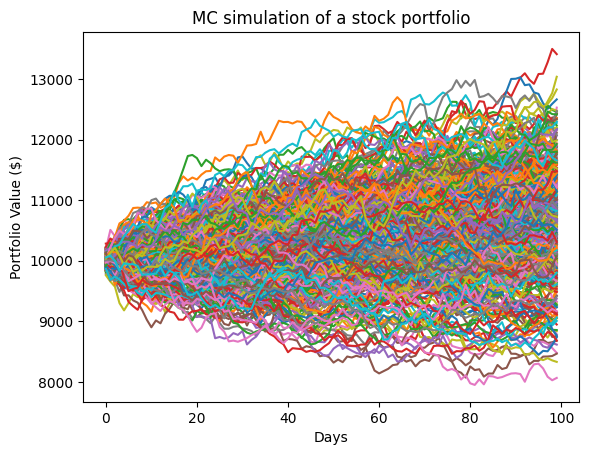

In [61]:
plt.plot(portfolio_sims)
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Days')
plt.title('MC simulation of a stock portfolio')
plt.show()

## Paso 4: En base a los resultados obtenemos el VaR y CVaR

In [62]:
portResults = pd.Series(portfolio_sims[-1,:])

VaR = initialPortfolio - RiskMetrics.VaR(portResults, alpha=5)
CVaR = initialPortfolio - RiskMetrics.CVaR(portResults, alpha=5)

print('VaR ${}'.format(round(VaR,2)))
print('CVaR ${}'.format(round(CVaR,2)))

VaR $889.04
CVaR $1232.12


# Análisis Técnico

El análisis técnico es una parte fundamental de las finanzas, en este caso se mostrará como elaborar los gráficos más útiles y usados dentro de las finanzas, que permiten visualizar el comportamiento de un activo a lo largo del tiempo. 

Tenemos dos formas principales de poder graficar en python el primero es usando la librería de matplotlib, el cual nos sirve para poder hacer gráficos estáticos, que son fáciles de hacer y no son tardadados en cargar.

### Graficar precios de cierre 

El gráfico de precios de cierre permite visualizar la evolución del precio de un activo a lo largo del tiempo, es la representación directa del comportamiento del mercado.

<Axes: xlabel='Date'>

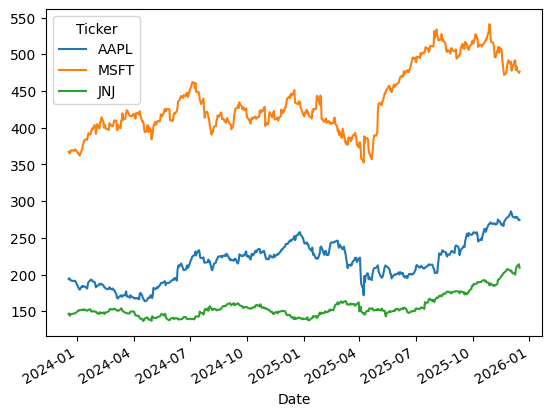

In [63]:
portfolio1_prices.plot()

### Graficar precios de cierre interactivo

In [64]:
import plotly.express as px

def plot_interactive_prices(portfolio_prices):
    
    #Primero convierte las fechas en el índice y luego los Assets en filas
    historic_prices = portfolio_prices.reset_index().melt(id_vars='Date', var_name='Activo', value_name='Precio')

   #Creamos la gráfica los precios de cierres interactivos
    plot_prices = px.line(historic_prices, x='Date', y='Precio', color='Activo',
                title='Precios históricos interactivos',
                labels={'Date': 'Fecha', 'Precio': 'Precio', 'Activo': 'Activo'})

    plot_prices.update_xaxes(rangeslider_visible=True)
    plot_prices.update_layout(width=950, height=550)
    plot_prices.show()

c:\users\980014096\appdata\local\programs\python\python39\lib\site-packages\plotly\io\_renderers.py:51: UserWarning:

Plotly version >= 6 requires Jupyter Notebook >= 7 but you have 6.5.3 installed.
 To upgrade Jupyter Notebook, please run `pip install notebook --upgrade`.



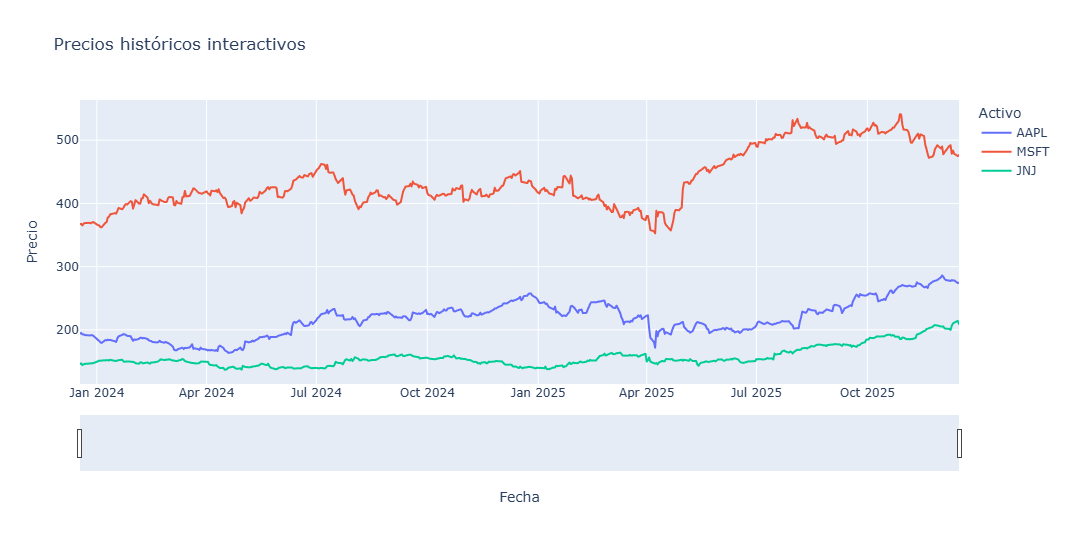

In [65]:
plot_interactive_prices(portfolio1_prices)

### Graficar precios de cierre base 0

Para poder comparar mejor la evolución en el precio del activo, normalizamos los precios, mostrando la variación relativa acumulada de cada activo, así comparamos el desempeño de los activos en una misma escala.

<Axes: xlabel='Date'>

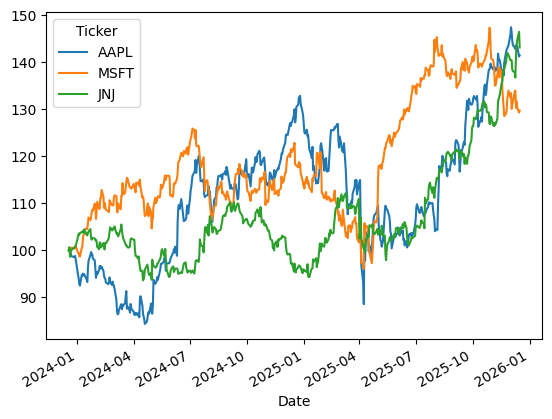

In [66]:
Assets_AbsChange = (portfolio1_prices / portfolio1_prices.iloc[0] * 100)
Assets_AbsChange.plot()

### Graficar precios de cierre base 0 interactivos

In [67]:
def plot_interactive_prices_base100(portfolio_prices):

    assets_abschange = (portfolio_prices / portfolio_prices.iloc[0] * 100)

    #Primero convierte las fechas en el índice y luego los Assets en filas
    assets_abschange_plot = assets_abschange.reset_index().melt(id_vars='Date', var_name='Activo', value_name='Precio')

    #Creamos la grafica los cambios porcentuales acumulados en base 0
    fig_base100 = px.line(assets_abschange_plot, x='Date', y='Precio', color='Activo',
                title='Cambio porcentual acumulado (Base 100)',
                labels={'Date': 'Fecha', 'Precio': 'Índice Base 100', 'Activo': 'Activo'})

    fig_base100.update_xaxes(rangeslider_visible=True)
    fig_base100.update_layout(width=950, height=550)

    #Hacemos gráfica lineal interactiva de los cambios porcentual base 0 
    fig_base100.show()

### Graficar rendimientos logaritmicos

Los rendimientos logarítmicos miden el cambio porcentual continuo en el precio de un activo entre dos periodos consecutivos. A diferencia de los rendimientos simples, los rendimientos logarítmicos son aditivos en el tiempo, lo que los hace especialmente útiles en análisis estadístico y modelación financiera.

Estas gráficas permiten analizar la volatilidad, identificar episodios de alta incertidumbre y estudiar la distribución de los rendimientos.

<Axes: xlabel='Date'>

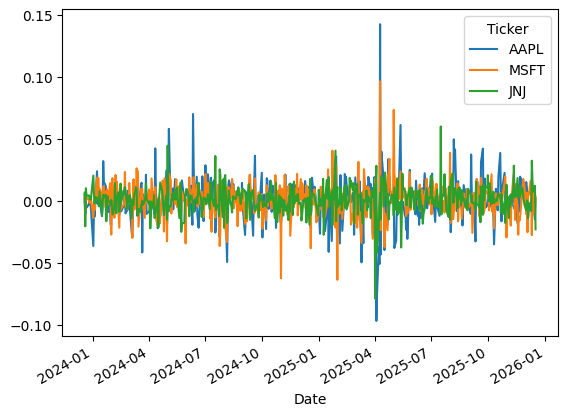

In [68]:
portfolio1_returns.plot()

### Gráfico de rendimientos logarítmicos interactivos

In [69]:
# --- Gráfico de rendimientos logarítmicos ---
def plot_interactive_returns(portfolio_returns):
    log_returns_long = (portfolio_returns.reset_index().melt(
            id_vars='Date',
            var_name='Activo',
            value_name='Rendimiento_Log'))

    fig_log_returns = px.line(
        log_returns_long,
        x='Date',
        y='Rendimiento_Log',
        color='Activo',
        title='Rendimientos logarítmicos interactivos',
        labels={
            'Date': 'Fecha',
            'Rendimiento_Log': 'Rendimiento logarítmico',
            'Activo': 'Activo'})

    fig_log_returns.update_xaxes(rangeslider_visible=True)
    fig_log_returns.update_layout(width=950, height=550)

    fig_log_returns.show()

### Simple Moving Averages

La media móvil simple (SMA) calcula el promedio aritmético de los precios durante un número fijo de periodos. Su objetivo es suavizar la serie de precios y resaltar la tendencia general del activo.

La SMA responde de manera lenta a cambios bruscos en el precio, por lo que es más adecuada para identificar tendencias de mediano y largo plazo.

In [70]:
def simple_moving_averages(portfolio_prices, ticket, window_short, window_long, opt='plot'):

    #Convertimos los precios del portafolio a un dataframe
    data = pd.DataFrame(portfolio_prices[ticket]).dropna()

    # Calculamos las medias móviles simples
    
    data['SMA1'] = data[ticket].rolling(window=window_short).mean()     #Media móvil corta
    data['SMA2'] = data[ticket].rolling(window=window_long).mean()    #Media móvil larga
    data['positions'] = np.where(data['SMA1'] > data['SMA2'], 1, -1)
    
    if opt =='plot':
        
        ax = data[[ticket, 'SMA1', 'SMA2']].plot(figsize=(15, 5))
        
    elif opt =='table':
        
        ax = data.tail()
    
    return ax

<Axes: xlabel='Date'>

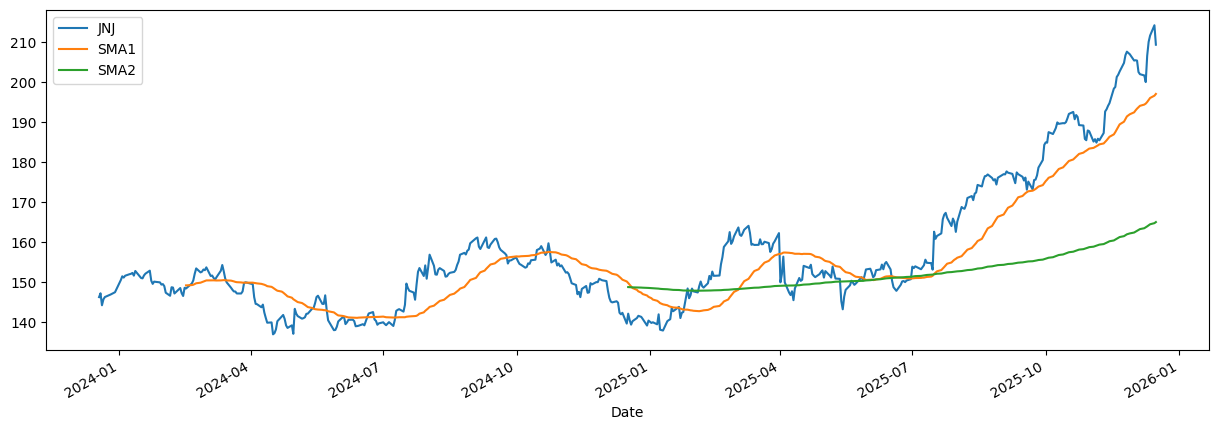

In [71]:
simple_moving_averages(portfolio1_prices, 'JNJ', 42, 252)

### Simple Moving Averages interactivo

In [72]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

def simple_moving_averages_interactive(portfolio_prices, ticket, window_short=20, window_long=50, opt='plot'):
    # Convertimos los precios del portafolio a un dataframe
    data = pd.DataFrame(portfolio_prices[ticket]).dropna()

    # Calculamos las medias móviles simples
    data['SMA1'] = data[ticket].rolling(window=window_short).mean()   # Media móvil corta
    data['SMA2'] = data[ticket].rolling(window=window_long).mean()    # Media móvil larga
    data['positions'] = np.where(data['SMA1'] > data['SMA2'], 1, -1)

    if opt == 'plot':
        fig = go.Figure()

        # Precio
        fig.add_trace(go.Scatter(
            x=data.index, y=data[ticket],
            mode='lines', name='Precio',
            line=dict(color='blue', width=2)
        ))

        # SMA corta
        fig.add_trace(go.Scatter(
            x=data.index, y=data['SMA1'],
            mode='lines', name=f'SMA {window_short}',
            line=dict(color='red', dash='dash')
        ))

        # SMA larga
        fig.add_trace(go.Scatter(
            x=data.index, y=data['SMA2'],
            mode='lines', name=f'SMA {window_long}',
            line=dict(color='green', dash='dot')
        ))

        # Layout interactivo
        fig.update_layout(
            title=f"Medias móviles simples ({ticket})",
            xaxis_title="Fecha",
            yaxis_title="Precio",
            hovermode="x unified",
            template="plotly",
            legend=dict(x=0, y=1)
        )

        return fig.show()

    elif opt == 'table':
        return data.tail()

    else:
        raise ValueError("opt debe ser 'plot' o 'table'")

### Exponential Moving Averages

La media móvil exponencial (EMA) asigna mayor peso a los precios más recientes, reaccionando más rápido a cambios en el mercado.
Gracias a esta característica, la EMA es más sensible a movimientos recientes y suele utilizarse para detectar cambios tempranos en la tendencia.

In [73]:
def exponential_moving_averages(portfolio_prices, ticket, window_short, window_long, opt='plot'):
    # Convertimos los precios del portafolio a un dataframe
    data = pd.DataFrame(portfolio_prices[ticket]).dropna()

    # Calculamos las medias móviles exponenciales
    data['EMA1'] = data[ticket].ewm(span=window_short, adjust=False).mean()  # Media exponencial corta
    data['EMA2'] = data[ticket].ewm(span=window_long, adjust=False).mean()   # Media exponencial larga
    data['positions'] = np.where(data['EMA1'] > data['EMA2'], 1, -1)

    if opt == 'plot':
        ax = data[[ticket, 'EMA1', 'EMA2']].plot(figsize=(15, 5))

    elif opt == 'table':
        ax = data.tail()

    return ax

<Axes: xlabel='Date'>

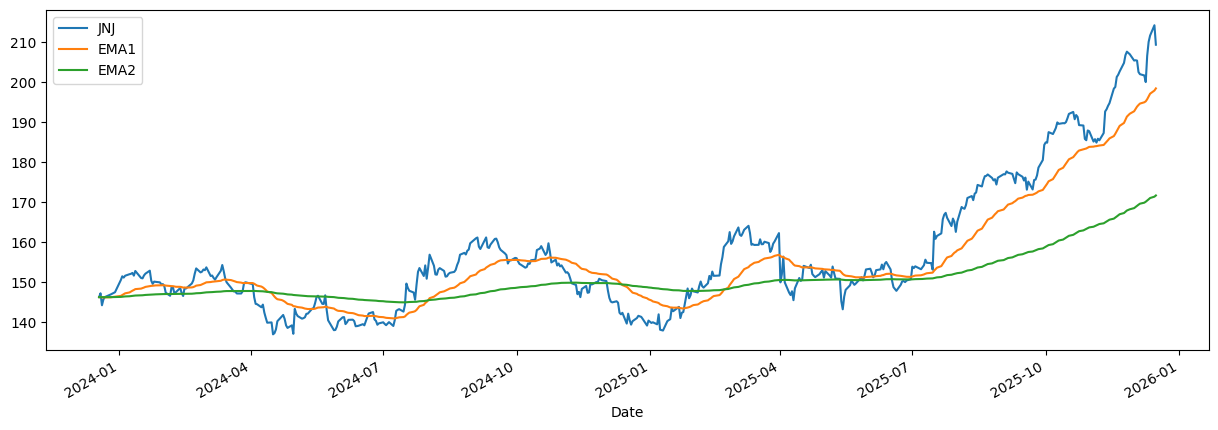

In [74]:
exponential_moving_averages(portfolio1_prices, 'JNJ', 42, 252)

### Exponential Moving Averages interactivo

In [75]:
from plotly.offline import init_notebook_mode, iplot
import plotly.graph_objs as go

init_notebook_mode(connected=True)

def exponential_moving_averages_iplot(portfolio_prices, ticket, window_short, window_long, opt='plot'):
    # Convertimos los precios del portafolio a un dataframe
    data = pd.DataFrame(portfolio_prices[ticket]).dropna()

    # Calculamos las medias móviles exponenciales
    data['EMA1'] = data[ticket].ewm(span=window_short, adjust=False).mean()
    data['EMA2'] = data[ticket].ewm(span=window_long, adjust=False).mean()
    data['positions'] = np.where(data['EMA1'] > data['EMA2'], 1, -1)

    if opt == 'plot':
        trace_price = go.Scatter(x=data.index, y=data[ticket], mode='lines', name=ticket)
        trace_ema1 = go.Scatter(x=data.index, y=data['EMA1'], mode='lines', name=f'EMA {window_short}')
        trace_ema2 = go.Scatter(x=data.index, y=data['EMA2'], mode='lines', name=f'EMA {window_long}')

        layout = go.Layout(
            title=f'EMAs para {ticket}',
            xaxis=dict(
                title='Fecha',
                rangeselector=dict(
                    buttons=list([
                        dict(count=1, label="1m", step="month", stepmode="backward"),
                        dict(count=3, label="3m", step="month", stepmode="backward"),
                        dict(count=6, label="6m", step="month", stepmode="backward"),
                        dict(count=1, label="1y", step="year", stepmode="backward"),
                        dict(step="all")
                    ])
                ),
                rangeslider=dict(visible=True),
                type="date"
            ),
            yaxis=dict(title='Precio'),
            hovermode='x unified'
        )

        fig = go.Figure(data=[trace_price, trace_ema1, trace_ema2], layout=layout)
        iplot(fig)

    elif opt == 'table':
        return data.tail()

### Bollinger bands

Las Bandas de Bollinger son un indicador técnico que permite evaluar la volatilidad y los posibles niveles de sobrecompra o sobreventa de un activo.
Las bandas de Bollinger tiene tres componentes:

- **Banda media:** La banda media es una SMA.
- **Banda superior:** es la SMA más un múltiplo de la desviación estándar.
- **Banda inferior:** la SMA menos un múltiplo de la desviación estándar.



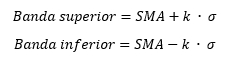

- SMA es la media móvil simple:
- σ es la desviación estándar
- k es un parámetro que controla la amplitud de las bandas (usualmente es 2)

In [76]:
def bollinger_bands(portfolio_prices, ticker, window=20, k=2, opt='plot'):

    data = pd.DataFrame(portfolio_prices[ticker]).dropna()

    # Media y desviación estándar
    data['sma'] = data[ticker].rolling(window=window).mean()
    data['std'] = data[ticker].rolling(window=window).std()

    # Bandas de Bollinger
    data['upper_band'] = data['sma'] + k * data['std']
    data['lower_band'] = data['sma'] - k * data['std']

    if opt == 'plot':
        ax = data[
            ['upper_band', 'sma', 'lower_band']
        ].iloc[-200:].plot(
            figsize=(15, 5),
            style=['g--', 'r--', 'g--'],
            lw=1
        )

        data[ticker].iloc[-200:].plot(ax=ax, lw=2)

        ax.set_title(f'Bandas de Bollinger ({window}, {k}) - {ticker}')
        ax.set_ylabel('Precio')

    elif opt == 'table':
        ax = data.tail()

    else:
        raise ValueError("opt must be 'plot' or 'table'")

    return ax


<Axes: title={'center': 'Bandas de Bollinger (20, 2) - AAPL'}, xlabel='Date', ylabel='Precio'>

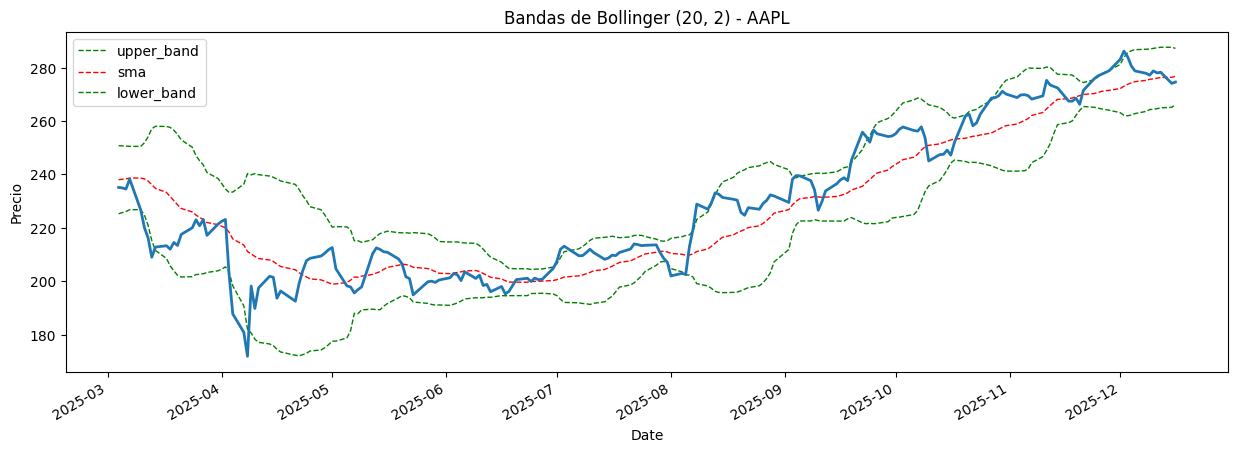

In [77]:
#Ejemplo
bollinger_bands(portfolio1_prices, 'AAPL')

### Bollinger bands interactivas

In [78]:
import pandas as pd
import plotly.graph_objects as go

def bollinger_bands_interactive(portfolio_prices, ticker, window=20, k=2):

    # Precios
    data = pd.DataFrame(portfolio_prices[ticker]).dropna()
    data.columns = [ticker]

    # Media y desviación estándar móviles
    data['sma'] = data[ticker].rolling(window=window).mean()
    data['std'] = data[ticker].rolling(window=window).std()

    # Bandas de Bollinger
    data['upper_band'] = data['sma'] + k * data['std']
    data['lower_band'] = data['sma'] - k * data['std']

    # Figura
    fig = go.Figure()

    # Precio
    fig.add_trace(go.Scatter(
        x=data.index,
        y=data[ticker],
        name='Precio',
        line=dict(color='blue')
    ))

    # Media
    fig.add_trace(go.Scatter(
        x=data.index,
        y=data['sma'],
        name='SMA',
        line=dict(color='red')
    ))

    # Banda superior
    fig.add_trace(go.Scatter(
        x=data.index,
        y=data['upper_band'],
        name='Banda superior',
        line=dict(color='green', dash='dot')
    ))

    # Banda inferior
    fig.add_trace(go.Scatter(
        x=data.index,
        y=data['lower_band'],
        name='Banda inferior',
        line=dict(color='green', dash='dot')
    ))

    # Layout (sin rangeselector, con rangeslider)
    fig.update_layout(
        title=f'Bandas de Bollinger ({window}, {k}) - {ticker}',
        xaxis=dict(
            rangeslider=dict(visible=True),
            type='date'
        ),
        xaxis_title='Fecha',
        yaxis_title='Precio',
        template='plotly_white',
        width=900,
        height=500
    )

    fig.show()


### Gráfico de velas

El gráfico de velas japonesas es el tal vez el gráfico financiera más reconocido y más utilizado a nivel mundial, el gráfico es permite observar el comportamiento del activo en diferentes temporalidades, lo que nos permite ver que pasó durante un día, una hora, una semana, e incluso en segundos.

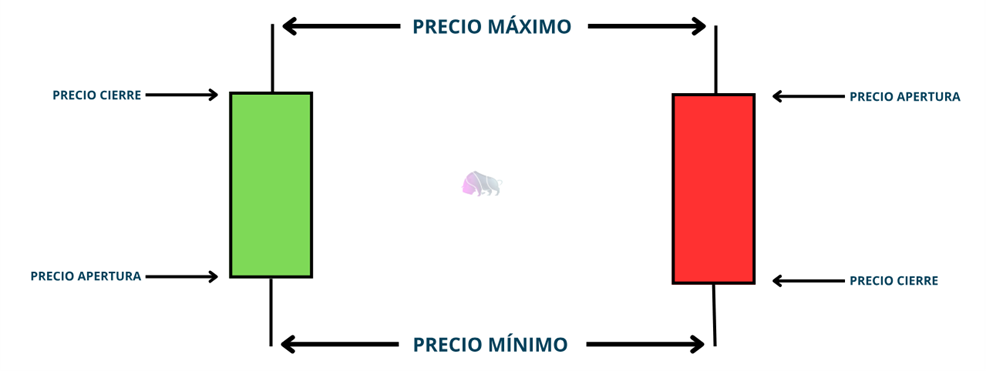

De manera sencilla cada vela consta de dos partes principales, que son la mecha y el cuerpo. El cuerpo muestra la diferencia entre el precio de apertura y el precio de cierre, mientras que la mecha muestra la diferencia entre el precio máximo y el precio mínimo. 
Para poner un ejemplo, digamos que estamos leyendo el gráfico de velas en un día, ese mismo día la acción apertura a un precio de 19, alcanzó un precio máximo de 22, bajó a un máximo de 18.75, y finalmente cerró en 20.50.

In [82]:
import yfinance as yf
import pandas as pd
import plotly.graph_objects as go

def plot_candlestick(df, ticker):
    fig = go.Figure()

    # Candlestick
    fig.add_trace(go.Candlestick(x=df.index, open=df['Open'], high=df['High'], low=df['Low'], close=df['Close'],
            increasing_line_color='green', decreasing_line_color='red', name='Precio'))

    # Layout con rangeselector y rangeslider
    fig.update_layout(
        title=f'Candlestick - {ticker}',
        xaxis=dict(rangeselector=dict(
                buttons=list([
                    dict(count=1, label="1m", step="month", stepmode="backward"),
                    dict(count=3, label="3m", step="month", stepmode="backward"),
                    dict(count=6, label="6m", step="month", stepmode="backward"),
                    dict(count=1, label="1y", step="year", stepmode="backward"),
                    dict(step="all")])),
                   
            rangeslider=dict(visible=False),
            type="date"
        ),
        yaxis=dict(title="Precio"),
        template='plotly_white', width=950, height=600)

    fig.show()

c:\users\980014096\appdata\local\programs\python\python39\lib\site-packages\plotly\io\_renderers.py:51: UserWarning:

Plotly version >= 6 requires Jupyter Notebook >= 7 but you have 6.5.3 installed.
 To upgrade Jupyter Notebook, please run `pip install notebook --upgrade`.



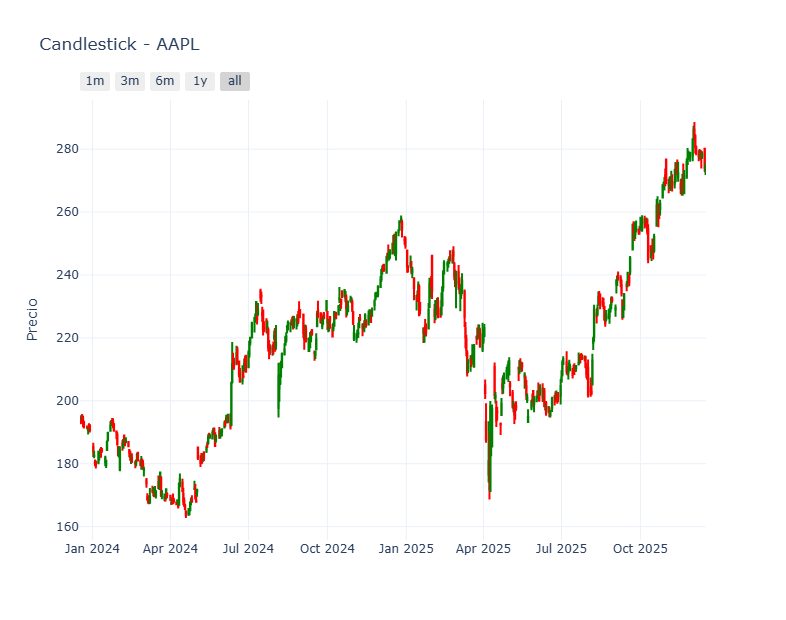

In [83]:
plot_candlestick(precios_AAPL, 'AAPL')

## Matemáticas financieras

In [9]:
InterestRate = (5500 / 5000) ** (1/4) - 1
print(InterestRate)

0.02411368908444511


## Future Value

In [5]:
years = 3
Capital = 5000
rate = 0.0435

Capital * (1 + rate)** years

5681.295314375001

## Net present value

In [3]:
cf =[-15000,5000,7000,10000]
r = 0.05

NPV = 0
for i in range(len(cf)):
    NPV += cf[i] / (1 + r) ** i
print(NPV)

4749.487096425871
